# Using Clojure in Jupyter

## Who am I

 - Jeff Cummings
 - Programming with:
   - Java 20 years
   - SQL 20 years
   - Clojure 8 years
 - Jupyter user 2 years
 - [@jtcummiatl](https://twitter.com/jtcummiatl)
 - https://www.linkedin.com/in/jeffrey-cummings-5b46015/
 - https://github.com/JeffAtAtl
 - jtcummi@yahoo.com

## Why should I use a language other than Python in Jupyter

Henry Garner wrote an article for InfoQ as part of their Getting a Handle on Data Science series.

The article was titled Data Science Up and Down the Ladder of Abstraction and in it he set out his reasons for adopting Clojure, including its:

 - Excellent tooling for REPL-driven development and notebooks for exploratory analysis and live charting.
 - Suitability for creating shareable browser-based visualisations and interactive simulations with modern UI frameworks like Facebook's React.
 - Interoperability with Java, JavaScript, and Scala for making use of established and actively developed numerical optimisation, distributed computing, and machine learning libraries.
 - Data-oriented functional core with a focus on composable sequence processing interfaces which scale with the volume of data you have.
 - Clean and unambiguous syntax which even aids my comprehension of transcribed algorithms.
 - Macro system which enables extensibility at the language level for custom algorithmic abstractions and cleaner code.
 
You can read the full article [here](https://www.infoq.com/articles/data-science-abstraction).

## So what does Clojure syntax look like

 - Clojure is a lisp so statements look like (func-name arg1 arg2 ...)
 - Go ahead try Hello, World!

In [4]:
(println "Hello, World!")

Hello, World!


 - Function names don't have to be words. Try some math functions:

In [5]:
(+ 1 2)

3

In [6]:
(/ 22 7)

22/7

In [7]:
(/ 22.0 7)

3.142857142857143

In [8]:
(+ 1 2 3 4 5)

15

 - You can define your own functions with defn. Use the following form to define a function named triple that triples its argument.

In [9]:
(defn triple [n] (* 3 n))

#'user/triple

### Some data types

 - numbers - 1 2.0 3M 2/3
 - booleans - true false
 - symbols - + triple defn
 - keywords - :a :first-name
 - strings - "Hello, World"
 - character literals - \a \b
 - lists - (1 2 3) (1 "one" :one) ()
 - vectors - \[1 2 3\] []
 - sets - #{1 2 3} #{}
 - maps - {:a 1 :b 2}
 - [For more info](http://45.79.209.162:8081/labs/its-all-data)

### Java Interopt

 - Clojure provides direct, unproxied access to Java. To call a static method use a form like (Classname/method arg1 arg2 ...)

In [10]:
(System/getProperty "java.class.path")

"/home/jtcummi/.local/share/jupyter/kernels/clojure/clojupyter"

 - You can also import and create instances of Java Classes. For now, stuff your instance into a global using def:

In [11]:
(import java.util.Date)

java.util.Date

In [12]:
(def now (Date.))

#'user/now

 - Passing a class instance to the "str" function is like calling the "toString" method on it.

In [13]:
(str now)

"Thu Jul 12 01:20:11 UTC 2018"

In [14]:
(.toString now)

"Thu Jul 12 01:20:11 UTC 2018"

 - You can also call any other puplic methods

In [15]:
(.getMonth now)

6

In [16]:
(.toGMTString now)

"12 Jul 2018 01:20:11 GMT"

 - Using the "type" function allow you to get more info about a class.

In [17]:
(type now)

java.util.Date

## How do you install clojupyter plug-in into Jupyter

 - Easiest to install on Linux or MacOs
 - Need Java installed 
 - Need to install [Leiningen](https://leiningen.org/) (Clojure build tool)
 - Install git client 
 - git clone https://github.com/clojupyter/clojupyter.git
 - follow directions at https://github.com/clojupyter/clojupyter
 
 - There is also a Docker container, if you have access to Docker
   - https://github.com/kxxoling/jupyter-clojure-docker
   - The only problem is that this is an older version of clojupyter

## Examples of what you can do with Clojure (clojupyter)

 - Create and read Excel spreadsheets

In [18]:
(require '[clojupyter.misc.helper :as helper])
(helper/add-dependencies '[com.vijaykiran/docjure "1.7.0"]) ; actually making a remote library available to us
(require '[dk.ative.docjure.spreadsheet :as ss])

In [19]:
;; Create a spreadsheet and save it
(let [wb (ss/create-workbook "Price List"
                          [["Name" "Price"]
                           ["Foo Widget" 100]
                           ["Bar Widget" 200]
                           ["Baz Widget" 300]
                           ["Biz Widget" 400]])
      sheet (ss/select-sheet "Price List" wb)
      header-row (first (ss/row-seq sheet))]
  (do
    (ss/set-row-style! header-row (ss/create-cell-style! wb {:background :yellow,
                                                       :font {:bold true}}))
    (ss/save-workbook! "spreadsheet.xlsx" wb)))

In [20]:
;; Read from spreadsheet just created
(->> (ss/load-workbook "spreadsheet.xlsx")
     (ss/select-sheet "Price List")
     (ss/select-columns {:A :name, :B :price})
     (map (juxt :name :price))
     clojure.pprint/pprint)

(["Name" "Price"]
 ["Foo Widget" 100.0]
 ["Bar Widget" 200.0]
 ["Baz Widget" 300.0]
 ["Biz Widget" 400.0])


 - Process Textual Data (word list)

In [22]:
(def words-file (slurp "data/words"))
(def words (clojure.string/split words-file #"\r\n"))

#'user/words

In [23]:
(count words)

234936

In [24]:
(take 5 words)

("A" "a" "aa" "aal" "aalii")

In [25]:
(reduce + (map count words))

2251877

In [26]:
(float (/ (reduce + (map count words)) 
          (count words)))

9.585066

In [27]:
(double (/ (reduce + (map count words)) 
           (count words)))

9.585065720025879

In [28]:
(->> words
     (map count)
     frequencies
     sort
     clojure.pprint/pprint)

([1 52]
 [2 155]
 [3 1351]
 [4 5110]
 [5 9987]
 [6 17477]
 [7 23734]
 [8 29926]
 [9 32380]
 [10 30867]
 [11 26010]
 [12 20460]
 [13 14937]
 [14 9763]
 [15 5924]
 [16 3377]
 [17 1813]
 [18 842]
 [19 428]
 [20 198]
 [21 82]
 [22 41]
 [23 17]
 [24 5])


Let's define some functions for "Word processing"

In [29]:
(defn lower [s] (.toLowerCase s))

(defn w2cf 
  [w] 
  (frequencies (sort (map (comp keyword lower str) (seq w)))))

(defn cf2wl
  [cf]
  (filter #(= cf (w2cf %)) words))


(defn find-matching-words 
  [w] 
  (filter #(and (= (count w) (count %)) 
                (= (w2cf w) (w2cf %)))  
          words))

#'user/find-matching-words

In [30]:
(w2cf "art")

{:a 1, :r 1, :t 1}

In [31]:
(w2cf "tar")

{:a 1, :r 1, :t 1}

In [32]:
(find-matching-words "tar")

("Art" "art" "rat" "tar" "tra")

Now we have a tool to solve ![Jumble](https://static.wixstatic.com/media/b95917_4d4e083db2e24179b5a303affa05ffcd.jpg/v1/fill/w_346,h_107,al_c,lg_1,q_80/b95917_4d4e083db2e24179b5a303affa05ffcd.webp "Jumble")

http://www.jumble.com/playjumble

In [33]:
(find-matching-words "ortgu")

("grout")

In [34]:
(find-matching-words "udefg")

("fudge")

 - Programatically create HTML

In [35]:
(require '[clojupyter.misc.display :as display])
(require '[clojure.repl :as repl])

In [36]:
(println ">> should print some text")
;; displaying html
(display/hiccup-html 
    [:ul 
     [:li "a " [:i "emphatic"] " idea"]
     [:li "a " [:b "bold"] " idea"]
     [:li "an " [:span {:style "text-decoration: underline;"} "important"] " idea"]
     [:li "test"]])

>> should print some text


a emphatic idea a bold idea an important idea test

Also can render SVG (within a table)

In [37]:
(defn style [& info]
  {:style (.trim (apply str (map #(let [[kwd val] %]
                                   (str (name kwd) ": " val "; "))
                                (apply hash-map info))))})
(defn svg-circle
    [color]
    [:svg {:height 100 :width 100 :xmlns "http://www.w3.org/2000/svg"}
            [:circle {:cx 50 :cy 50 :r 40 :fill color}]])

(display/hiccup-html
    [:table (style :border "1px solid black")
     [:tr 
      [:td (style :border "1px solid black")
       (svg-circle "green")]
      [:td (style :border "1px solid black")
       (svg-circle "red")]]
     [:tr 
      [:td (style :border "1px solid black")
       (svg-circle "red")]
      [:td (style :border "1px solid black")
       (svg-circle "green")]]])

,
,


 - Adding External Javascript Dependency
 
 Since you can render arbitrary HTML using `display/hiccup-html`, it's pretty easy to use external Javascript libraries to do things like generate charts. Here's an example using [Highcharts](https://www.highcharts.com/).

First, we use a cell to add javascript to the running notebook:

In [38]:
(helper/add-javascript "https://code.highcharts.com/highcharts.js")

Now we define a function which takes Clojure data and returns hiccup HTML to display:

In [39]:
(require '[clojure.data.json :as json])

In [40]:
(defn plot-highchart [highchart-json]
  (let [id (str (java.util.UUID/randomUUID))
        code (format "Highcharts.chart('%s', %s );" id, (json/write-str highchart-json))]
      (display/hiccup-html 
        [:div [:div {:id id :style {:background-color "red"}}]
                   [:script code]])))

#'user/plot-highchart

Now we can make generate interactive plots (try hovering over plot):

In [41]:
(def raw-data (map #(+ (* 22 (+ % (Math/random)) 78)) (range)))
(def data-1 (take 500 raw-data))
(def data-2 (reverse (take 500 raw-data)))
(def data-3 (map #(/ (+ %1 %2) 2) data-1 data-2))

(plot-highchart {:chart {:type "line"}
                 :title {:text "Plot of random data"}
                 :series [{:data data-1} {:data data-2} {:data data-3}]})

 - Call JSON Web Service and process

In [42]:
; Get # of Marta busses on road currently
(->> (json/read-str (slurp "http://developer.itsmarta.com/BRDRestService/RestBusRealTimeService/GetAllBus") :key-fn keyword)
     count)

262

In [43]:
; get info on all busses on specific route
(->> (json/read-str (slurp "http://developer.itsmarta.com/BRDRestService/RestBusRealTimeService/GetAllBus") :key-fn keyword)
     (filter #(= (:ROUTE %) "1"))
     (map (juxt :ROUTE
                :MSGTIME
                :DIRECTION
                :VEHICLE
                ;:LONGITUDE
                ;:LATITUDE
                ;:STOPID
                ;:BLOCK_ABBR
                ;:BLOCKID
                :TIMEPOINT
                ;:TRIPID
                :ADHERENCE))
     sort
     (apply map list) ; these 3 lines add a row number to row
     (concat (list (rest (range))))
     (apply map list)
     (concat [["#" "ROUTE" "MSGTIME" "DIRECTION" "VEHICLE" "TIMEPOINT" "ADHERENCE"]]) ; add header
     clojure.pprint/pprint)

(["#" "ROUTE" "MSGTIME" "DIRECTION" "VEHICLE" "TIMEPOINT" "ADHERENCE"]
 (1
  "1"
  "7/11/2018 9:28:17 PM"
  "Northbound"
  "1470"
  "W Marietta St & Joseph Lowery Bv"
  "-5")
 (2
  "1"
  "7/11/2018 9:39:36 PM"
  "Southbound"
  "1560"
  "West End Station"
  "0")
 (3
  "1"
  "7/11/2018 9:40:55 PM"
  "Northbound"
  "1570"
  "West End Station"
  "-1"))


 - using [Incanter](http://incanter.org/)
 
 If a cell returns a Java [BufferedImage](https://docs.oracle.com/javase/7/docs/api/java/awt/image/BufferedImage.html), then Clojupyter will render the image. This makes it easy to use Java charting libraries, like [Incanter](https://github.com/incanter/incanter), where the chart can be converted into an image easily. First let's bring in some helper namespaces and bring in Incanter:

In [44]:
(require '[clojupyter.misc.helper :as helper])
(require '[clojupyter.misc.display :as display])

(helper/add-dependencies '[incanter/incanter "1.5.7"]
                         :repositories {"central" "https://repo1.maven.org/maven2/", "clojars" "https://clojars.org/repo"})
(helper/add-dependencies '[org.clojure/math.numeric-tower "0.0.4"]
                         :repositories {"central" "https://repo1.maven.org/maven2/", "clojars" "https://clojars.org/repo"})

(require '[clojure.core.reducers :as r])
(use '(incanter core stats charts io))

##### Since Incanter simply wraps the Java charting library [JFreeChart](https://github.com/incanter/incanter), we can call 
`(.createBufferedImage chart width height)` on any Incanter chart to get an imafge we can render as cell output:

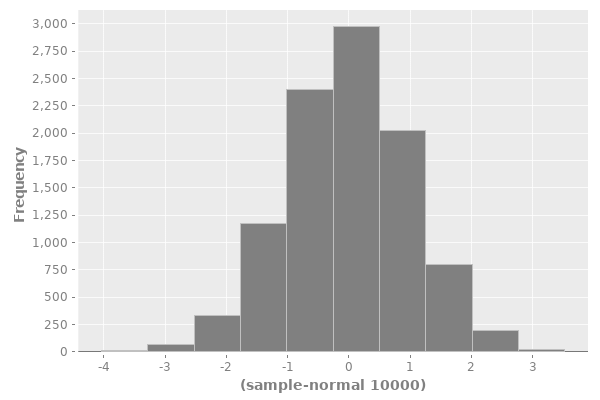

In [45]:
(-> (sample-normal 10000)
    histogram
    (.createBufferedImage 600 400))

Here's an example of a scatter plot:

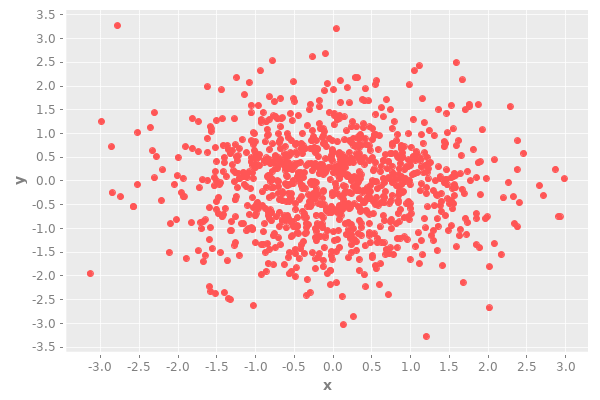

In [46]:
(-> (scatter-plot (sample-normal 1000) 
                  (sample-normal 1000)
                  :x-label "x" :y-label "y")
    (.createBufferedImage 600 400)) 

## Next Steps

 - Create docker container with latest version of clojupyter
 - Create more helper functions
 - Create better documentation
 - Blog about my experiences

## Acknowledgements

 - [Rich Hickey](https://github.com/richhickey) for Clojure
 - [Rory Kirchner](https://github.com/roryk) and [Aria Haghighi](https://github.com/aria42) for [clojupyter](https://github.com/clojupyter/clojupyter)
 - [Kane Blueriver](https://github.com/kxxoling/jupyter-clojure-docker) for clojupyter docker image